<a href="https://colab.research.google.com/github/daveveed/Geo-Data-Science/blob/main/Spatial_Join.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import geopandas as gpd, os, requests

In [2]:
input_folder = 'data'
output_folder = 'output'

if not os.path.exists(input_folder):
    os.makedirs(input_folder)
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [3]:
def download(url):

  filename = os.path.join(input_folder, os.path.basename(url))

  if not os.path.exists(filename):
    response = requests.get(url, allow_redirects=True)

    with open(filename, 'wb') as file:
      file.write(response.content)
  print(f'Downloaded {os.path.basename(url)}')


In [4]:
url_link = 'https://raw.githubusercontent.com/daveveed/Geo-Data-Science/main/Data/Temp/addresses.gpkg'

In [5]:
download(url_link)

Downloaded addresses.gpkg


In [7]:
addresses = gpd.read_file(os.path.join(input_folder, 'addresses.gpkg'))
addresses.head()

/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'addresses.gpkg': 'addresses' (default), 'addresses_with_population_data'. Specify layer parameter to avoid this warning.
  result = read_func(


,address,geometry
0,"Ruoholahti, 14, Itämerenkatu, Ruoholahti, Läns...",POINT (24.91556 60.1632)
1,"1, Kampinkuja, Kamppi, Eteläinen suurpiiri, He...",POINT (24.93009 60.16846)
2,"Espresso House, 8, Kaivokatu, Keskusta, Kluuvi...",POINT (24.94153 60.17016)
3,"Hermannin rantatie, Verkkosaari, Kalasatama, S...",POINT (24.97853 60.1905)
4,"9, Tyynenmerenkatu, Jätkäsaari, Länsisatama, E...",POINT (24.92169 60.15667)


In [9]:
population_grid = gpd.read_file(
    (
        "https://kartta.hsy.fi/geoserver/wfs"
        "?service=wfs"
        "&version=2.0.0"
        "&request=GetFeature"
        "&typeName=asuminen_ja_maankaytto:Vaestotietoruudukko_2020"
        "&srsName=EPSG:3879"
    ),
)
population_grid.crs = "EPSG:3879"  # for WFS data, the CRS needs to be specified manually

In [12]:
population_grid.head(2)

,gml_id,index,asukkaita,asvaljyys,ika0_9,ika10_19,ika20_29,ika30_39,ika40_49,ika50_59,ika60_69,ika70_79,ika_yli80,geometry
0,Vaestotietoruudukko_2020.1,703,5,51,99,99,99,99,99,99,99,99,99,"POLYGON ((25472499.995 6685998.998, 25472499.9..."
1,Vaestotietoruudukko_2020.2,710,8,44,99,99,99,99,99,99,99,99,99,"POLYGON ((25472499.995 6684249.004, 25472499.9..."


In [13]:
population_grid.to_file(os.path.join(output_folder, 'population_grid.gpkg'), driver='GPKG')

As a first step before making a spatial join, it is always good to check that the coordinate reference system (CRS) of the layers are identical. The basic requirement for a successful spatial join is that the layers should overlap with each other in space. If the geometries between the layers do not share the same CRS, it is very likely that the spatial join will fail and produces an empty GeoDataFrame.

In [14]:
addresses.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [15]:
population_grid.crs.name

'ETRS89 / GK25FIN'

### reproject

In [16]:
addresses = addresses.to_crs(crs=population_grid.crs)

In [17]:
addresses.crs == population_grid.crs

True

In [25]:
new_names = {'asukkaita': 'inhabitants',
             'asvaljyys': 'occupancy_rate'}
pop_grid = population_grid.rename(columns=new_names, inplace = True)

In [26]:
pop_grid = population_grid[['inhabitants', 'occupancy_rate', 'geometry', 'index']]
pop_grid.head()

,inhabitants,occupancy_rate,geometry,index
0,5,51,"POLYGON ((25472499.995 6685998.998, 25472499.9...",703
1,8,44,"POLYGON ((25472499.995 6684249.004, 25472499.9...",710
2,5,90,"POLYGON ((25472499.995 6683999.005, 25472499.9...",711
3,13,34,"POLYGON ((25472499.995 6682998.998, 25472499.9...",715
4,5,53,"POLYGON ((25472749.993 6690249.003, 25472749.9...",848


<Axes: >

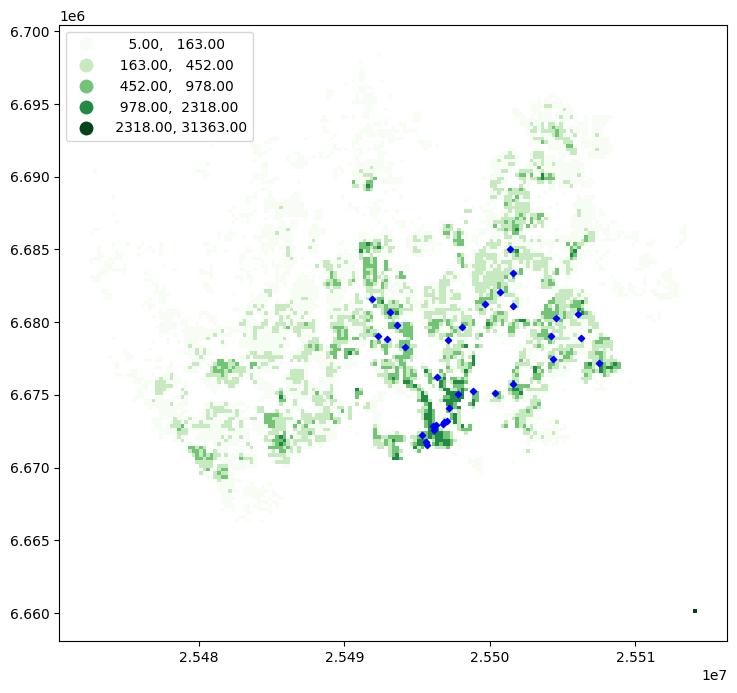

In [27]:
ax = pop_grid.plot(column='inhabitants',
                   cmap='Greens', scheme='naturalbreaks',
                   k=5, legend=True,
                   legend_kwds={'loc': 'upper left'},
                   figsize=(10, 8))
addresses.plot(ax=ax, color='blue', markersize=10, marker='D')



In [28]:
join = addresses.sjoin(pop_grid, predicate='within', how='inner')
join.head()

,address,geometry,index_right0,inhabitants,occupancy_rate,index
0,"Ruoholahti, 14, Itämerenkatu, Ruoholahti, Läns...",POINT (25495311.608 6672258.695),3247,492,34,15500
1,"1, Kampinkuja, Kamppi, Eteläinen suurpiiri, He...",POINT (25496118.86 6672844.074),3362,182,26,15984
2,"Espresso House, 8, Kaivokatu, Keskusta, Kluuvi...",POINT (25496754.115 6673032.35),3485,45,58,16469
4,"9, Tyynenmerenkatu, Jätkäsaari, Länsisatama, E...",POINT (25495650.78 6671530.714),3293,1410,33,15665
5,"18, Kontulantie, Kontula, Mellunkylä, Itäinen ...",POINT (25504528.607 6680282.118),5036,48,0,21462


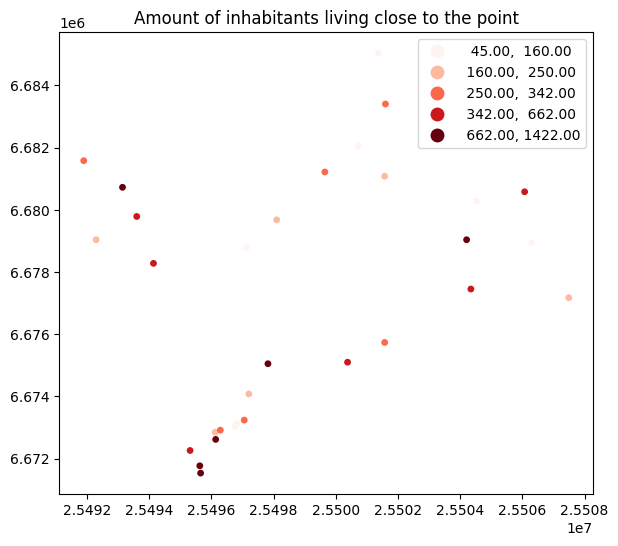

In [29]:
ax = join.plot(
    column="inhabitants",
    cmap="Reds",
    markersize=15,
    scheme="quantiles",
    legend=True,
    figsize=(10, 6),
)
ax.set_title("Amount of inhabitants living close to the point");